In [72]:
%matplotlib inline

import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import matplotlib.lines as mlines
import matplotlib as mpl

from eval_utils import load_model_results, lift_compression_args, include_peft, add_rank

# Custom plotting utilities (assume these exist in your path)
from plot.color import Color
from plot.formatter import LabelFormatter, NumberFormatter, Scale, Grid, LambdaFormatter, Decorator, PercentFormatter

### Matplotlib configuration

In [73]:
plt.rcParams["text.usetex"] = False
mpl_params = {
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
}
plt.rcParams.update(mpl_params)

### Notebook parameters

In [74]:
results_file = "/home/neubauer/src/comp-economics/compression_results.json"
x_col = "total_params"
y_col = "compression_factor"
save_path = "plot.png"  # None to disable saving

### Load and normalize results

In [75]:
print(f"Loading results from {results_file}")
dict_results = load_model_results(results_file)

# Lift compression args and flatten structure
dict_results = {k: lift_compression_args(v).get("compression", {}) for k, v in dict_results.items()}

# Include PEFT info and ranking
dict_results = include_peft(dict_results)
dict_results = add_rank(dict_results)
print(f"Loaded {len(dict_results)} runs")

# Save normalized results for inspection
with open("loaded_results.json", "w") as f:
    json.dump(dict_results, f, indent=2)

print("Saved normalized results to loaded_results.json")

#TODO: handle quantized adapters

Loading results from /home/neubauer/src/comp-economics/compression_results.json
Loaded 56 runs
Saved normalized results to loaded_results.json


### Convert to DataFrame

In [ ]:
df = pd.DataFrame.from_dict(dict_results, orient="index").reset_index().rename(columns={"index": "run_key"})
df = df.fillna(0)

#MB = 1024 * 1024
#df["adapter_size_bytes"] = df["adapter_size_bytes"] / MB

# Standardize encoding names
df["encoding"] = df["encoding"].replace({"huffman": "HC", "bitpacked": "BP"})

# Compute derived metrics
#TODO: question - does it already include the bitmask size? 
df["compressed_size_bytes"] = df["original_size_bytes"] / df["compression_factor"]


# TODO: check if effective compression factor is correct 
df["effective_compression_factor"] = df["original_size_bytes"] / (
    df["compressed_size_bytes"] + df["adapter_size_mb"] / (1024 * 1024))

print(df["effective_compression_factor"].describe())

df.head(5)

count    56.000000
mean      5.910252
std       1.984397
min       2.866968
25%       2.873464
50%       6.673414
75%       7.493444
max       7.790813
Name: effective_compression_factor, dtype: float64


,run_key,chunk_length,chunk_size,original_size_bytes,arithmetic_code_size_bytes,bitmap_size_bytes,final_size_bytes,pure_compression_factor,compression_factor,input_tokens_count,...,text_input,reduce_tokens,batch_size,engine,encoding,print_results,peft,rank,compressed_size_bytes,effective_compression_factor
0,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,59993.000,10818.0,70811.000,8.878603,7.522193,53263600,...,0,True,16,transformer,AC,False,vera,4.0,70811.000,7.522193
1,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,60163.375,10818.0,70981.375,8.853459,7.504138,53263600,...,0,True,16,transformer,AC,False,vera,4.0,70981.375,7.504138
2,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,60088.375,10818.0,70906.375,8.864510,7.512075,53263600,...,0,True,16,transformer,AC,False,vera,8.0,70906.375,7.512075
3,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,60042.875,10818.0,70860.875,8.871227,7.516898,53263600,...,0,True,16,transformer,AC,False,vera,16.0,70860.875,7.516898
4,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,59646.750,10818.0,70464.750,8.930143,7.559155,53263600,...,0,True,16,transformer,AC,False,vera,64.0,70464.750,7.559155


### Column labels & plotting mappings

In [77]:
LABELS = {
    "total_params": "Model Parameters",
    "compression_factor": "Compression Ratio",
    "pure_compression_factor": "Pure Compression Ratio",
    "adapter_params": "Adapter Parameters",
    "base_model_params": "Base Model Parameters",
    "base_model_size_mb": "Base Model Size (MB)",
    "adapter_size_mb": "Adapter Size (MB)",
    "throughput_kibibytes_per_sec": "Compression Throughput (KiB/s)",
    "final_size_bytes": "Compressed Size (bytes)",
    "peft": "PEFT Method",
    "encoding": "Encoding Method",
    "rank": "Rank (r) of Adapters (if applicable)",
}

SCALES = {
    "total_params": "log",
    "throughput_kibibytes_per_sec": "log",
    "final_size_bytes": "log",
}

COLOR_BY_PEFT = {None: "tab:gray", "lora": "tab:blue", "vera": "tab:orange"}
MARKER_BY_ENCODING = {"AC": "o", "HC": "s", "BP": "D", None: "x"}

def pretty_label(col):
    return LABELS.get(col, col.replace("_", " ").title())

def normalize_marker_sizes(series, min_size=25, max_size=200):
    val_min, val_max = series.min(), series.max()
    return min_size + (max_size - min_size) * (series - val_min) / (val_max - val_min + 1e-9)


In [78]:
# print all column names
print("Columns in DataFrame:", df.columns.tolist())

Columns in DataFrame: ['run_key', 'chunk_length', 'chunk_size', 'original_size_bytes', 'arithmetic_code_size_bytes', 'bitmap_size_bytes', 'final_size_bytes', 'pure_compression_factor', 'compression_factor', 'input_tokens_count', 'entropy', 'total_compression_time', 'tokenize_time', 'compression_time', 'inference_time', 'ac_time', 'data_copy_time', 'softmax_time', 'throughput_tokens_per_sec', 'throughput_kibibytes_per_sec', 'inference_throughput_tokens_per_sec', 'inference_throughput_kibibytes_per_sec', 'total_params', 'adapter_params', 'base_model_params', 'total_size_mb', 'adapter_size_mb', 'base_model_size_mb', 'mode', 'input_path', 'output_path', 'model_name', 'lora_path', 'context_length', 'retain_tokens', 'first_n_tokens', 'use_kv_cache', 'text_input', 'reduce_tokens', 'batch_size', 'engine', 'encoding', 'print_results', 'peft', 'rank', 'compressed_size_bytes', 'effective_compression_factor']


### Plotting function

In [79]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

def plot_scatter_with_legend(df, x, y, marker_size_col=None, title=None, save_path=None):
    fig, ax = plt.subplots(figsize=(8,5))
    
    # Normalize marker sizes
    if marker_size_col:
        min_val = df[marker_size_col].min()
        max_val = df[marker_size_col].max()
        df['marker_size'] = 25 + 200 * (df[marker_size_col] - min_val) / (max_val - min_val + 1e-9)
    else:
        df['marker_size'] = 60
    
    # Plot points
    for _, r in df.iterrows():
        ax.scatter(
            r[x], r[y],
            color=COLOR_BY_PEFT.get(r.get("peft", None), "black"),
            marker=MARKER_BY_ENCODING.get(r.get("encoding", None), "o"),
            s=r['marker_size'], alpha=0.85
        )
    
    # Labels
    ax.set_xlabel(pretty_label(x))
    ax.set_ylabel(pretty_label(y))
    if title:
        ax.set_title(title)
    
    # Legends
    legend_elements = []
    
    # PEFT colors
    for peft, color in COLOR_BY_PEFT.items():
        legend_elements.append(Line2D([], [], color=color, marker='o', linestyle='None', markersize=7,
                                      label=f"PEFT: {peft}" if peft else "No PEFT"))
    
    # Encoding markers
    for enc, marker in MARKER_BY_ENCODING.items():
        if enc is None: continue
        legend_elements.append(Line2D([], [], color='black', marker=marker, linestyle='None', markersize=7,
                                      label=f"Encoding: {enc}"))
    
    # Bubble sizes (use Line2D with markersize proportional to scatter)
    #if marker_size_col:
    #    size_vals = np.linspace(df[marker_size_col].min(), df[marker_size_col].max(), 4)
    #    for val in size_vals:
    #        size = 25 + 200 * (val - df[marker_size_col].min()) / (df[marker_size_col].max() - df[marker_size_col].min() + 1e-9)
    #        legend_elements.append(Line2D([], [], color='gray', marker='o', linestyle='None', markersize=np.sqrt(size),
    #                                      label=f"{int(val):,}"))
    
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved plot to {save_path}")
    
    plt.show()

Saved plot to compression_vs_params.png


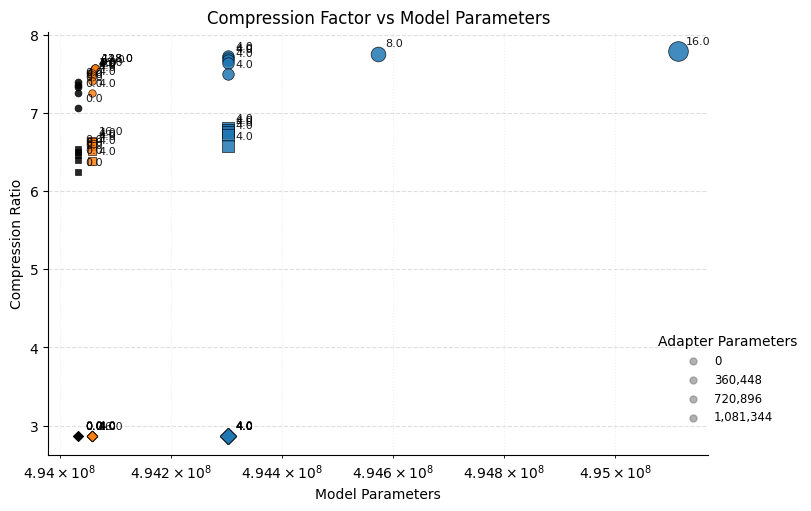

In [80]:
plot_scatter(df, x='total_params', y='compression_factor', marker_size_col='adapter_params',
             title="Compression Factor vs Model Parameters", save_path="compression_vs_params.png")

4.0 7.522192879637345 494057536 AC
4.0 7.504137529034906 494057536 AC
8.0 7.512074901586775 494057728 AC
16.0 7.516898429493003 494058112 AC
64.0 7.559155464256951 494060416 AC
128.0 7.56742472944511 494063488 AC
128.0 7.56742472944511 494063488 AC
16.0 7.790813154988701 495114112 AC
8.0 7.756748786765643 494573440 AC
4.0 7.724310949579908 494303104 AC
4.0 6.801679816503511 494303104 HC
16.0 6.634684071708607 494058112 HC
16.0 2.866968082243393 494058112 BP
4.0 2.866968082243393 494303104 BP
0.0 2.866968082243393 494032768 BP
0.0 6.531174275226264 494032768 HC
0.0 7.3919021359196355 494032768 AC
4.0 7.504137529034906 494057536 AC
4.0 7.699120096843551 494303104 AC
4.0 7.478430264494922 494057536 AC
0.0 7.359971259503881 494032768 AC
4.0 7.6785457507212325 494303104 AC
4.0 7.4548803977585845 494057536 AC
0.0 7.3241206721117615 494032768 AC
4.0 7.630462888351688 494303104 AC
4.0 7.402251648956775 494057536 AC
0.0 7.254321542510631 494032768 AC
4.0 7.489879282585616 494303104 AC
4.0 7.254

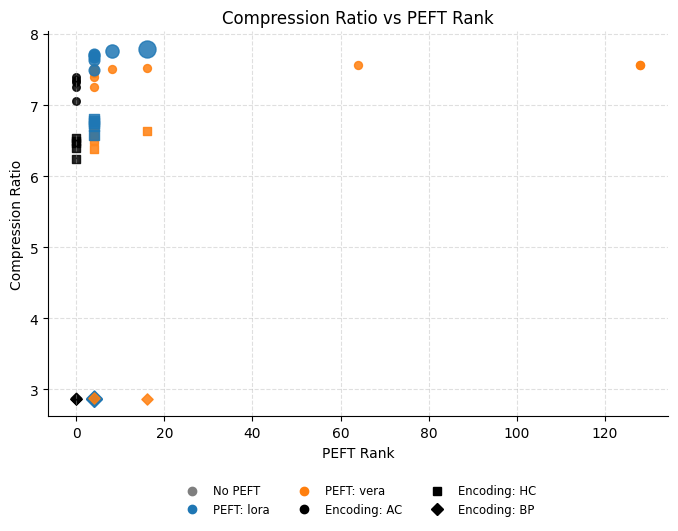

In [81]:
# --- Setup ---
plt.figure(figsize=(8, 5))
ax = plt.gca()

# --- Normalize marker size by total_params for visibility ---
# Scale total_params to a reasonable marker size range (e.g., 30–150)
param_min = df['total_params'].min()
param_max = df['total_params'].max()
df['marker_size'] = 30 + 120 * (df['total_params'] - param_min) / (param_max - param_min + 1e-9)

# --- Plot each run ---
for _, r in df.iterrows():
    ax.scatter(
        r['rank'],                  # x-axis is now rank
        r[y_col],                   # y-axis is still your selected metric
        color=COLOR_BY_PEFT.get(r["peft"], "black"),
        marker=MARKER_BY_ENCODING.get(r["encoding"], "o"),
        s=r['marker_size'],       # size proportional to total_params
        alpha=0.85,
    )

    print(r['rank'], r[y_col], r['total_params'], r['encoding'])  # Debug print to check values

# --- Axis scales ---
if y_col in SCALES:
    ax.set_yscale(SCALES[y_col])

ax.set_xlabel("PEFT Rank")
ax.set_ylabel(pretty_label(y_col))
ax.set_title(f"{pretty_label(y_col)} vs PEFT Rank")

# --- Build legend ---
legend_elements = []

# PEFT colors
for peft, color in COLOR_BY_PEFT.items():
    label = f"PEFT: {peft}" if peft else "No PEFT"
    legend_elements.append(
        mlines.Line2D([], [], color=color, marker='o', linestyle='None', markersize=6, label=label)
    )

# Encoding markers
for enc, marker in MARKER_BY_ENCODING.items():
    if enc is None:
        continue
    legend_elements.append(
        mlines.Line2D([], [], color='black', marker=marker, linestyle='None', markersize=6, label=f"Encoding: {enc}")
    )

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
    fontsize='small'
)

# --- Grid and spines ---
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Save figure ---
if save_path:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved plot to {save_path}")

plt.show()

Saved plot to pure_compression_factor_vs_rank.png


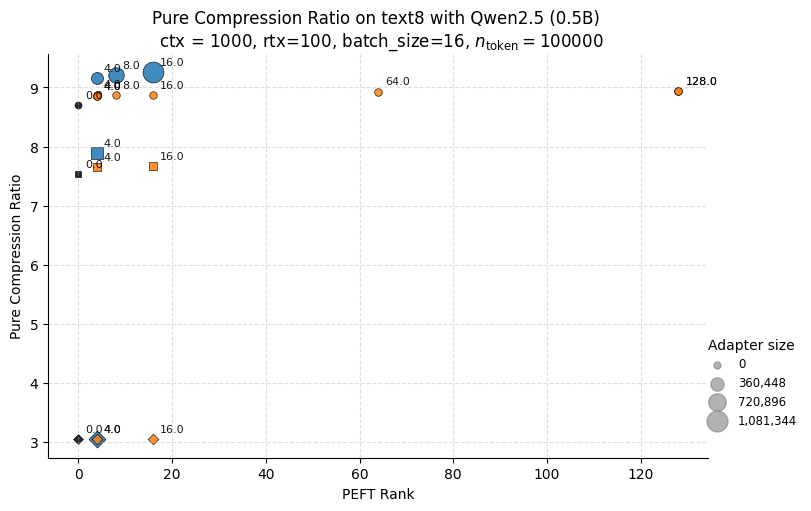

In [82]:
y_col = 'pure_compression_factor'
save_path = "pure_compression_factor_vs_rank.png"
filter = 'batch_size'
filter_value = 16

# --- Setup figure with automatic layout ---
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True) #dpi=200)

# --- Define color/marker mappings ---
#COLOR_BY_PEFT = {None: "tab:gray", "lora": "tab:blue", "vera": "tab:orange"}

# --- Normalize marker size by adapter_params ---
param_min = df['adapter_params'].min()
param_max = df['adapter_params'].max()

def size_fn(x):
    return 25 + 200 * (x - param_min) / (param_max - param_min + 1e-9)

df['marker_size'] = df['adapter_params'].apply(size_fn)

def restrict_df(df, filter, value):
    if filter not in df.columns:
        print(f"Warning: filter column '{filter}' not found in DataFrame. No filtering applied.")
        return df
    return df[df[filter] == value]

df = restrict_df(df, filter, filter_value)

# --- Plot points ---
for _, r in df.iterrows():
    if pd.isna(r['rank']) or pd.isna(r[y_col]) or pd.isna(r['adapter_params']):
        continue

    x = r['rank']
    y = r[y_col]

    ax.scatter(
        x,
        y,
        color=COLOR_BY_PEFT.get(r["peft"], "black"),
        marker=MARKER_BY_ENCODING.get(r["encoding"], "o"),
        s=r['marker_size'],
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5
    )

    # --- Add rank label ---
    ax.annotate(
        x,          # convert to string
        (x, y),                  # position
        textcoords="offset points",
        xytext=(5, 5),           # small offset to avoid overlap
        fontsize=8,
        alpha=0.9,
    )

# --- Labels ---
ax.set_xlabel("PEFT Rank")
ax.set_ylabel(pretty_label(y_col))
ax.set_title(f"{pretty_label(y_col)} on text8 with Qwen2.5 (0.5B) \n ctx = 1000, rtx=100, {filter}={filter_value}, $n_{{\\text{{token}}}} = 100000$")

# --- Grid styling ---
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================
# Legends
# ============================================================

# --- Color legend (PEFT type) ---
color_legend = [
    Line2D([], [], color=color, marker='o', linestyle='None',
           markersize=7, label=f"PEFT: {peft}" if peft else "No PEFT")
    for peft, color in COLOR_BY_PEFT.items()
]

# --- Marker legend (Encoding) ---
marker_legend = [
    Line2D([], [], color='black', marker=marker, linestyle='None',
           markersize=7, label=f"Encoding: {enc}")
    for enc, marker in MARKER_BY_ENCODING.items()
    if enc is not None
]

# --- Bubble size legend ---
size_values = np.linspace(param_min, param_max, 4)
size_legend = [
    plt.scatter([], [], s=size_fn(val), color='gray', alpha=0.6,
                label=f"{int(val):,}")
    for val in size_values
]

# Add legends separately so they don't override each other
legend1 = ax.legend(
    handles=color_legend + marker_legend,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
)

ax.add_artist(legend1)

legend2 = ax.legend(handles=size_legend,
                    title="Adapter size",
                    loc='lower right',
                    bbox_to_anchor=(1.15, 0.05),
                    ncol = 1,
                    frameon=False,
                    fontsize='small')

# --- Save figure ---
#if save_path:
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

plt.show()

Saved plot to effective_compression_factor_vs_rank.png


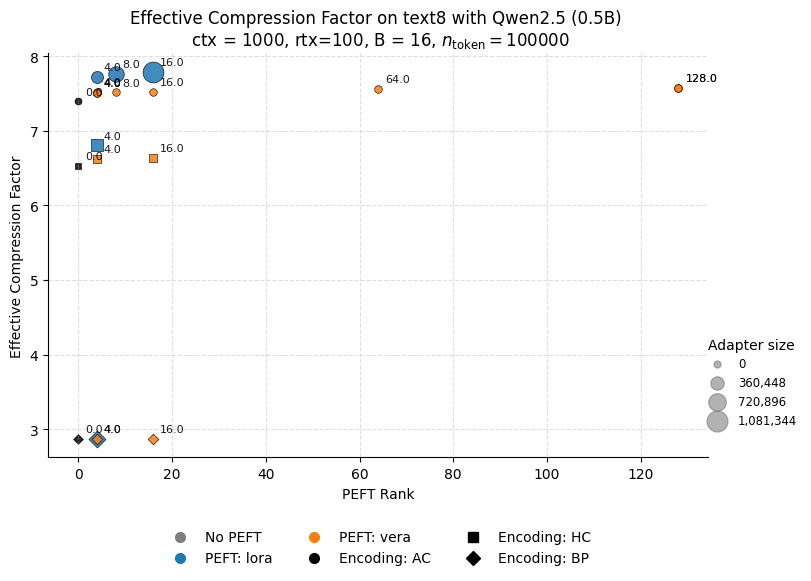

In [83]:
y_col = "effective_compression_factor"
save_path = "effective_compression_factor_vs_rank.png"

# --- Setup figure with automatic layout ---
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True) #dpi=200)

# --- Define color/marker mappings ---
#COLOR_BY_PEFT = {None: "tab:gray", "lora": "tab:blue", "vera": "tab:orange"}

# --- Normalize marker size by adapter_params ---
param_min = df['adapter_params'].min()
param_max = df['adapter_params'].max()

def size_fn(x):
    return 25 + 200 * (x - param_min) / (param_max - param_min + 1e-9)

df['marker_size'] = df['adapter_params'].apply(size_fn)

# --- Plot points ---
for _, r in df.iterrows():
    if pd.isna(r['rank']) or pd.isna(r[y_col]) or pd.isna(r['adapter_params']):
        continue

    x = r['rank']
    y = r[y_col]

    ax.scatter(
        x,
        y,
        color=COLOR_BY_PEFT.get(r["peft"], "black"),
        marker=MARKER_BY_ENCODING.get(r["encoding"], "o"),
        s=r['marker_size'],
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5
    )

    # --- Add rank label ---
    ax.annotate(
        x,          # convert to string
        (x, y),                  # position
        textcoords="offset points",
        xytext=(5, 5),           # small offset to avoid overlap
        fontsize=8,
        alpha=0.9,
    )

# --- Labels ---
ax.set_xlabel("PEFT Rank")
ax.set_ylabel(pretty_label(y_col))
ax.set_title(f"{pretty_label(y_col)} on text8 with Qwen2.5 (0.5B) \n ctx = 1000, rtx=100, B = 16, $n_{{\\text{{token}}}} = 100000$")

# --- Grid styling ---
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================
# Legends
# ============================================================

# --- Color legend (PEFT type) ---
color_legend = [
    Line2D([], [], color=color, marker='o', linestyle='None',
           markersize=7, label=f"PEFT: {peft}" if peft else "No PEFT")
    for peft, color in COLOR_BY_PEFT.items()
]

# --- Marker legend (Encoding) ---
marker_legend = [
    Line2D([], [], color='black', marker=marker, linestyle='None',
           markersize=7, label=f"Encoding: {enc}")
    for enc, marker in MARKER_BY_ENCODING.items()
    if enc is not None
]

# --- Bubble size legend ---
size_values = np.linspace(param_min, param_max, 4)
size_legend = [
    plt.scatter([], [], s=size_fn(val), color='gray', alpha=0.6,
                label=f"{int(val):,}")
    for val in size_values
]

# Add legends separately so they don't override each other
legend1 = ax.legend(
    handles=color_legend + marker_legend,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
)

ax.add_artist(legend1)

legend2 = ax.legend(handles=size_legend,
                    title="Adapter size",
                    loc='lower right',
                    bbox_to_anchor=(1.15, 0.05),
                    ncol = 1,
                    frameon=False,
                    fontsize='small')

# --- Save figure ---
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

plt.show()

#TODO: fix color legend (no grey yet)
#TODO: verify for non-adapter models effective compression factor  